# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
from Tools.DatasetTools.Commoms import *
dataset = 'Fe-Mo'  # 'Cr-Co-W'#'Fe-Mo
target_case = 'EF_nmhcp'
components = dataset.split('-')
# sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer  import Featurizer
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

# Compositions 

# Population of phases

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


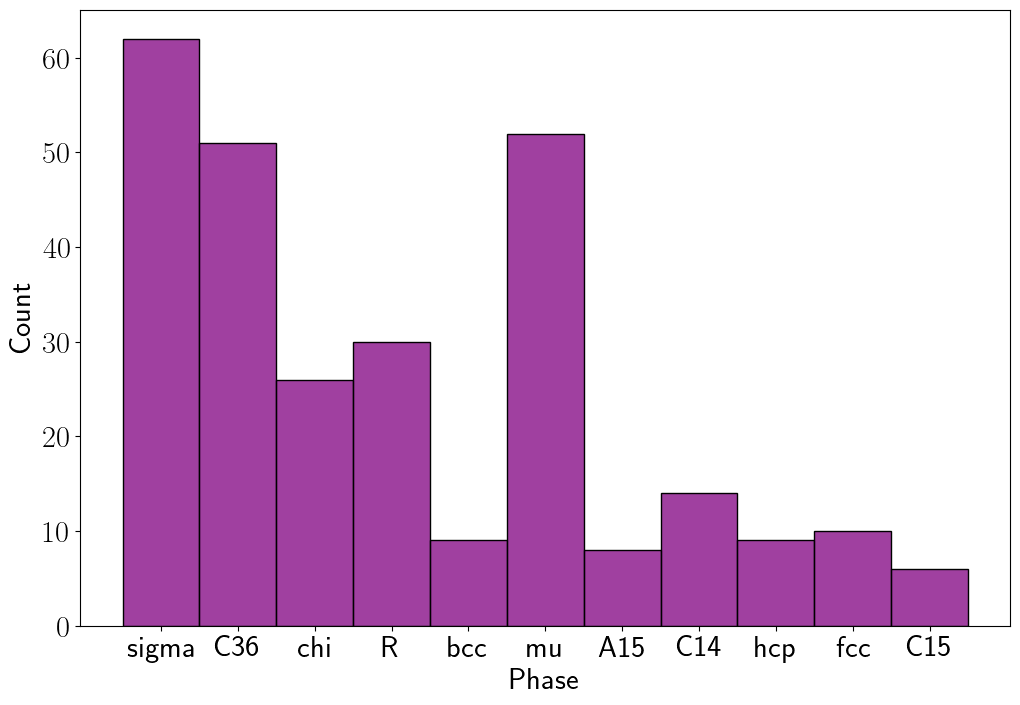

In [3]:
fig, ax = plt.subplots(figsize=(12,8))#, figsize=(12,8))
# sns.histplot(x = BS['Phase'], ax=ax)
#ax.hist(BS['Phase'])
ax = sns.histplot(x=BS['Phase'][BS['Phase']!='delta'], ax=ax, color='purple')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.eps')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.pdf')

In [4]:
BS['Phase'].value_counts()

sigma    62
mu       52
C36      51
R        30
chi      26
C14      14
fcc      10
bcc       9
hcp       9
A15       8
C15       6
delta     1
Name: Phase, dtype: int64

## Remove samples with very little representation

In [5]:
BS = BS[BS['Phase'] != 'delta']

# Extra features 

In [6]:
Features = Featurizer(BS)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


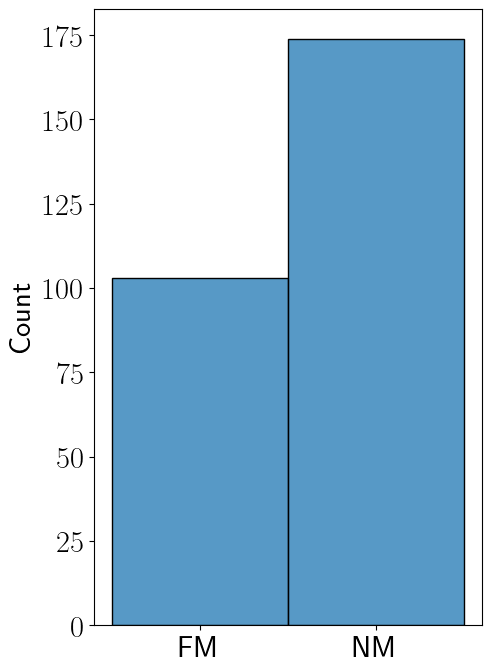

In [7]:
fig, ax = plt.subplots(figsize=(5,8))
sns.histplot(x = Features.Mag, ax=ax)
fig.savefig(f'{dataset}/graphs/{dataset}_FM_NM_counts.eps')

In [8]:
isfm = Features.Mag.str.contains('FM')

In [9]:
fmsamples = BS.index[isfm]

In [10]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [11]:
nmsamples = BS.index[~isfm]

## nm samples without fm counterpart:

In [12]:
nmsamples.difference(fmsamplesasnm)

Index(['Fe_pv1.bcc.NM', 'Fe_pv10Mo_sv14.C36-ABBAB.NM',
       'Fe_pv10Mo_sv14.C36-ABBBA.NM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv10Mo_sv14.C36-BABBA.NM', 'Fe_pv11Mo_sv2.mu-AAABA.NM',
       'Fe_pv11Mo_sv2.mu-AABAA.NM', 'Fe_pv12Mo_sv12.C36-AAABB.NM',
       'Fe_pv12Mo_sv17.chi-BBAB.NM', 'Fe_pv13Mo_sv16.chi-ABAB.NM',
       'Fe_pv14Mo_sv10.C36-AABAB.NM', 'Fe_pv14Mo_sv10.C36-AABBA.NM',
       'Fe_pv14Mo_sv10.C36-ABAAB.NM', 'Fe_pv14Mo_sv10.C36-BAABA.NM',
       'Fe_pv14Mo_sv16.sigma-AABAB.NM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv16Mo_sv13.chi-BAAB.NM', 'Fe_pv16Mo_sv8.C36-ABBAA.NM',
       'Fe_pv17Mo_sv12.chi-AAAB.NM', 'Fe_pv18Mo_sv6.C36-AAABA.NM',
       'Fe_pv19Mo_sv34.R-ABAABABBBBB.NM', 'Fe_pv1Mo_sv1.L10-NiAl-AB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM',
       'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM', 'Fe_pv21Mo_sv32.R-AAABAABBBBB.NM',
       'Fe_pv23Mo_sv30.R-AABABABABAB.NM', 'Fe_pv24Mo_sv29.R-BBAAAABBBBB.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABB

## fm samples as without nm counterpart:

In [13]:
fmsamplesasnm.difference(nmsamples)

Index(['Fe_pv1.fcc.NM', 'Fe_pv2.bcc-cubic.NM', 'Fe_pv30.sigma_Fe_pv.NM'], dtype='object')

# Distribution of Target Variables 

## total energy

In [14]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

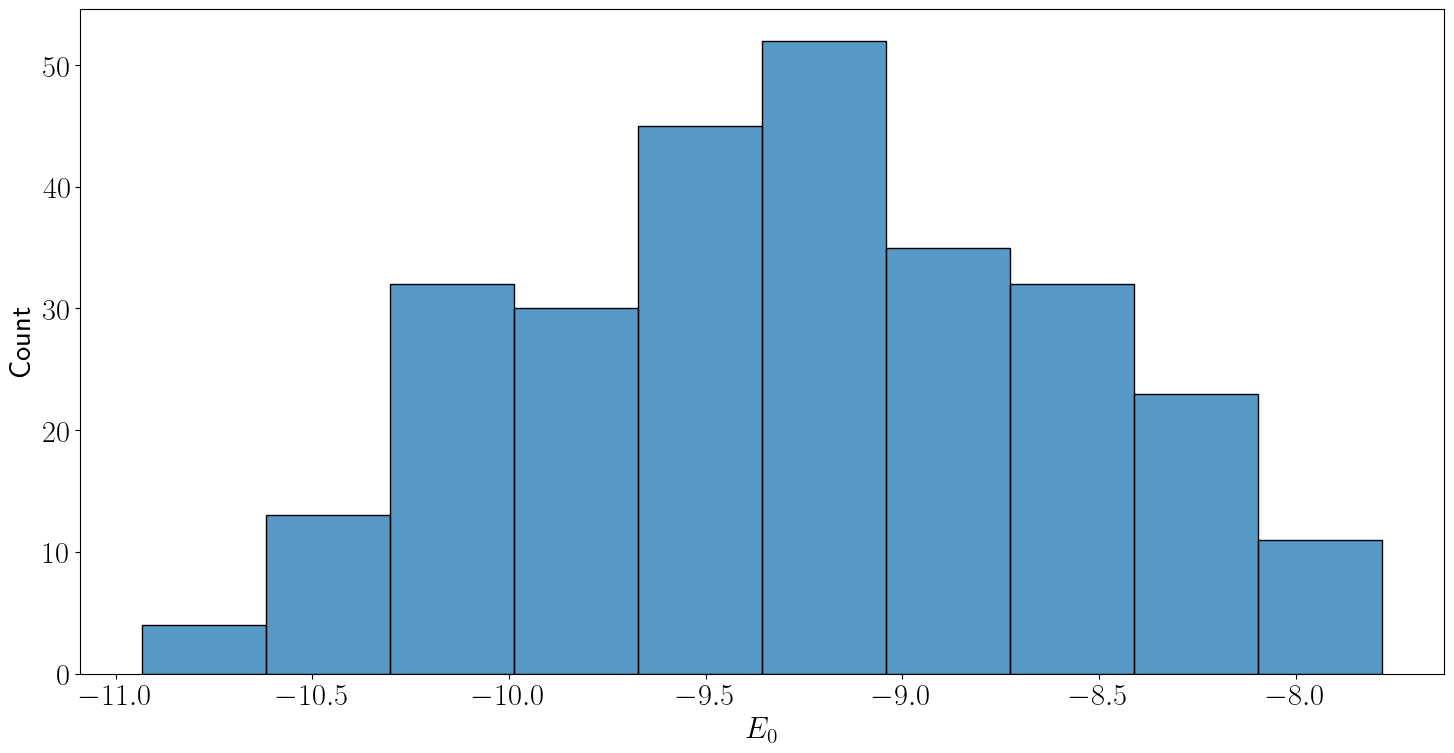

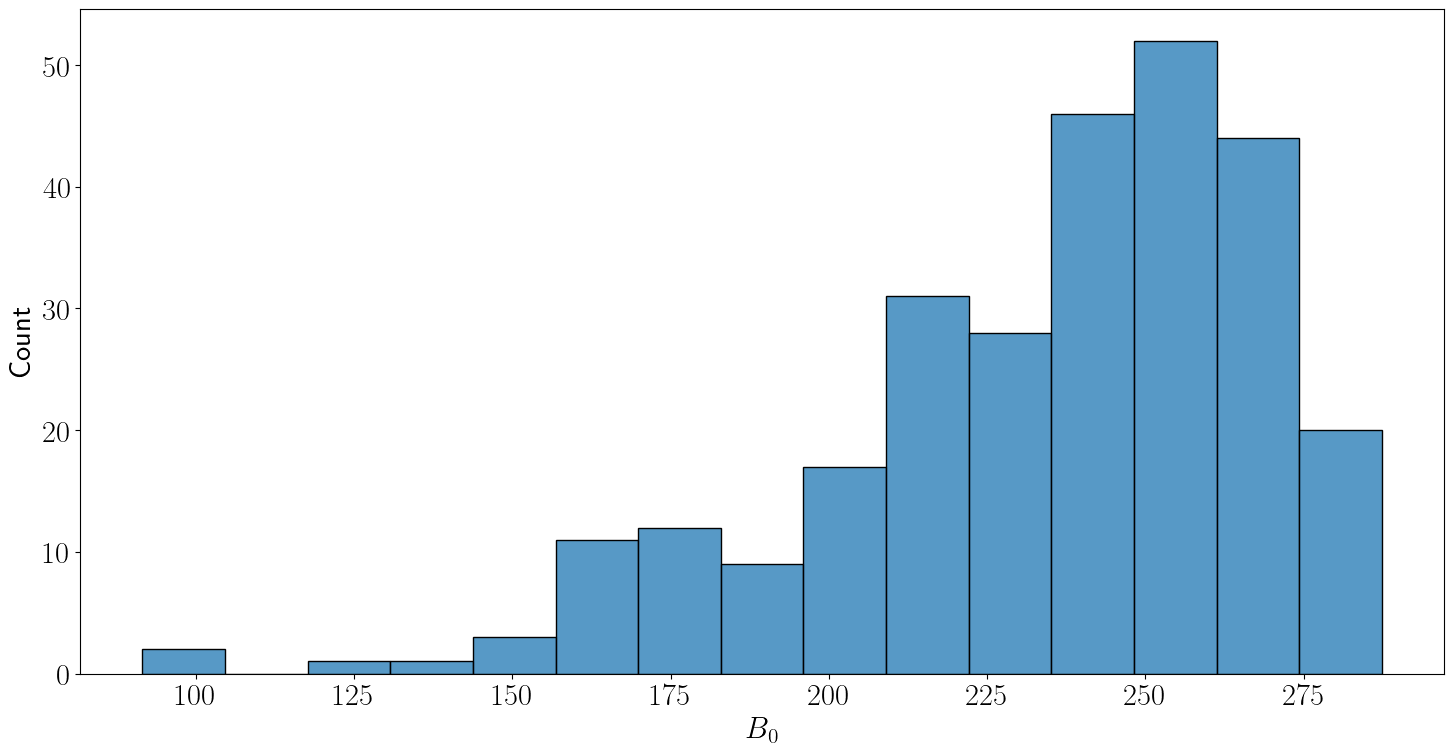

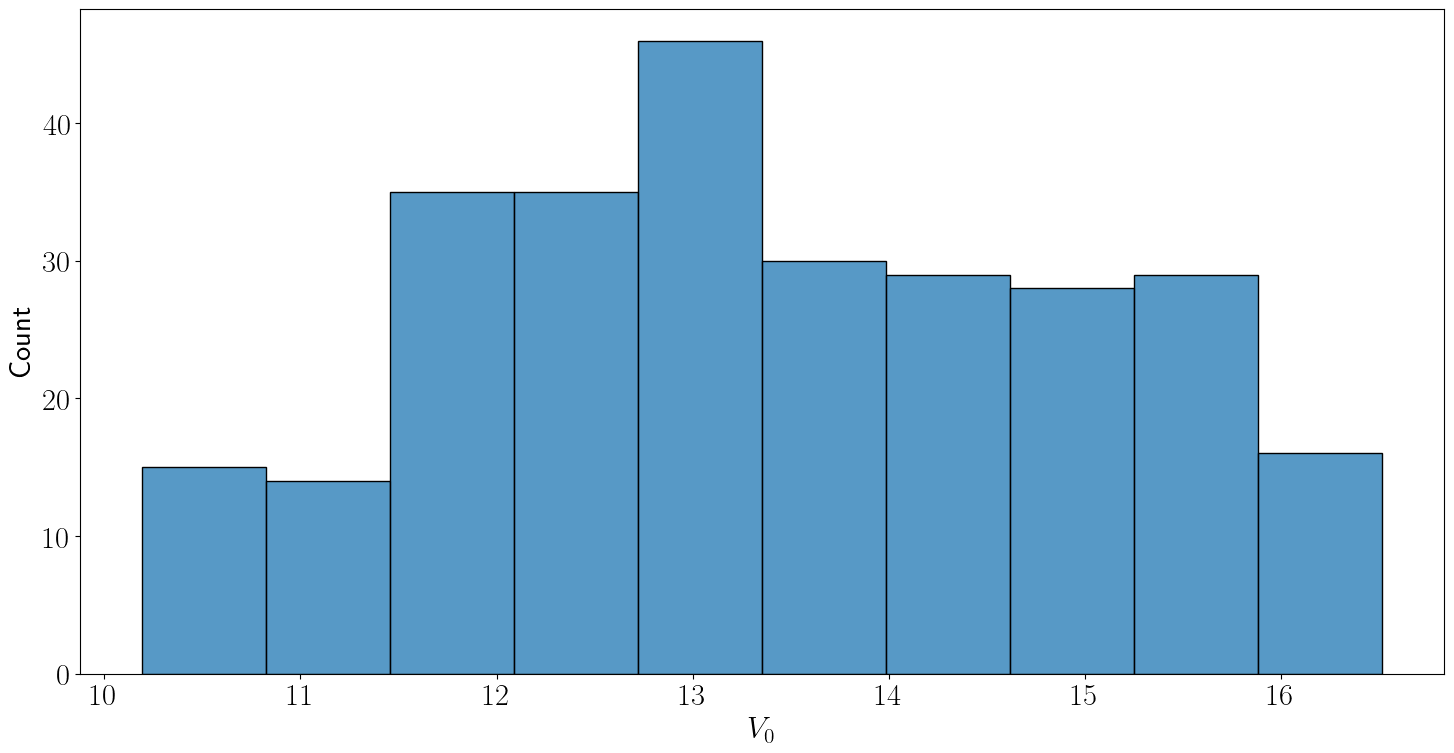

In [15]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [16]:
BS.sort_values(by='B0', inplace=True)

In [17]:
targets[target_case] = '$\\Delta E_f$'

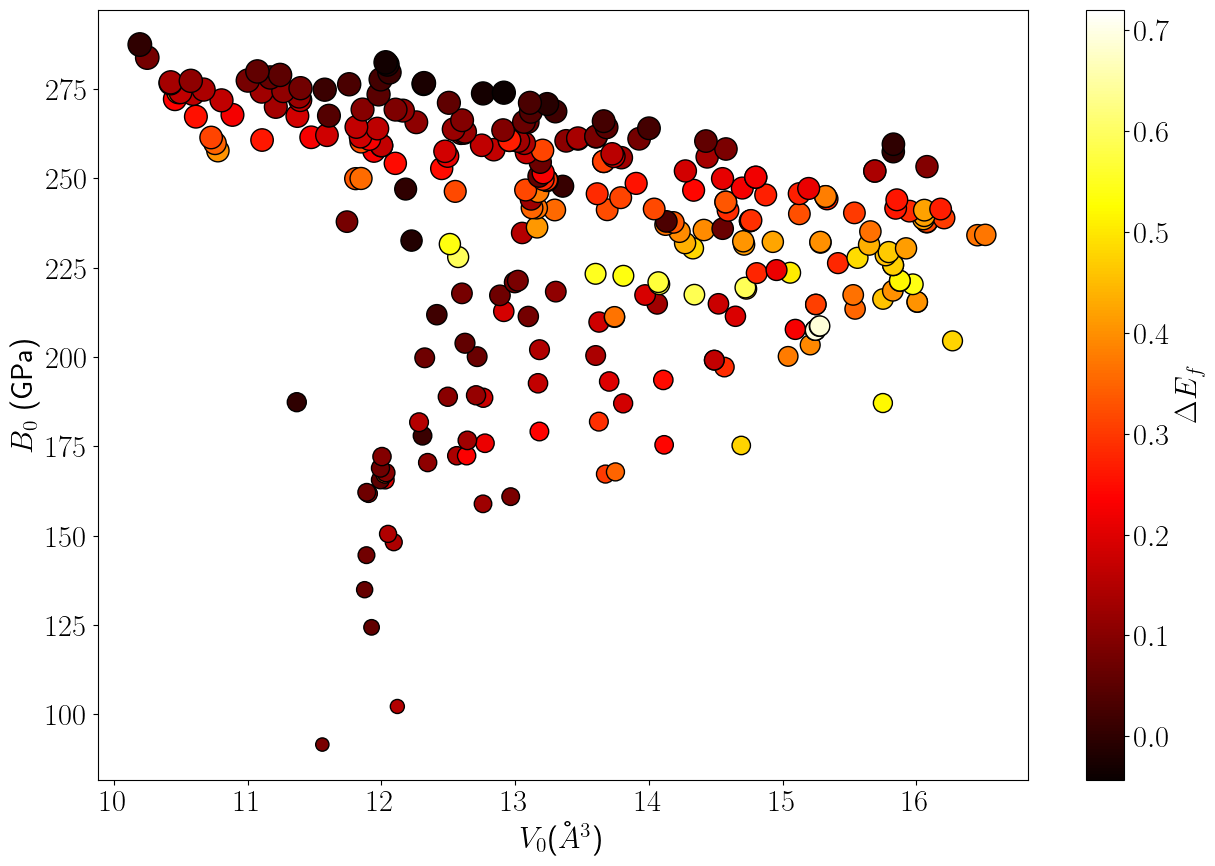

In [18]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.B0, c=BS[target_case], marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['B0']+' (GPa)')
plt.xlabel(targets['V0']+'($\\AA^3$)')
cbar.set_label(targets[target_case])

# Pair Plots

In [19]:
ToPlot = BS[list(targets.keys())]
ToPlot.columns = list(targets.values()) 

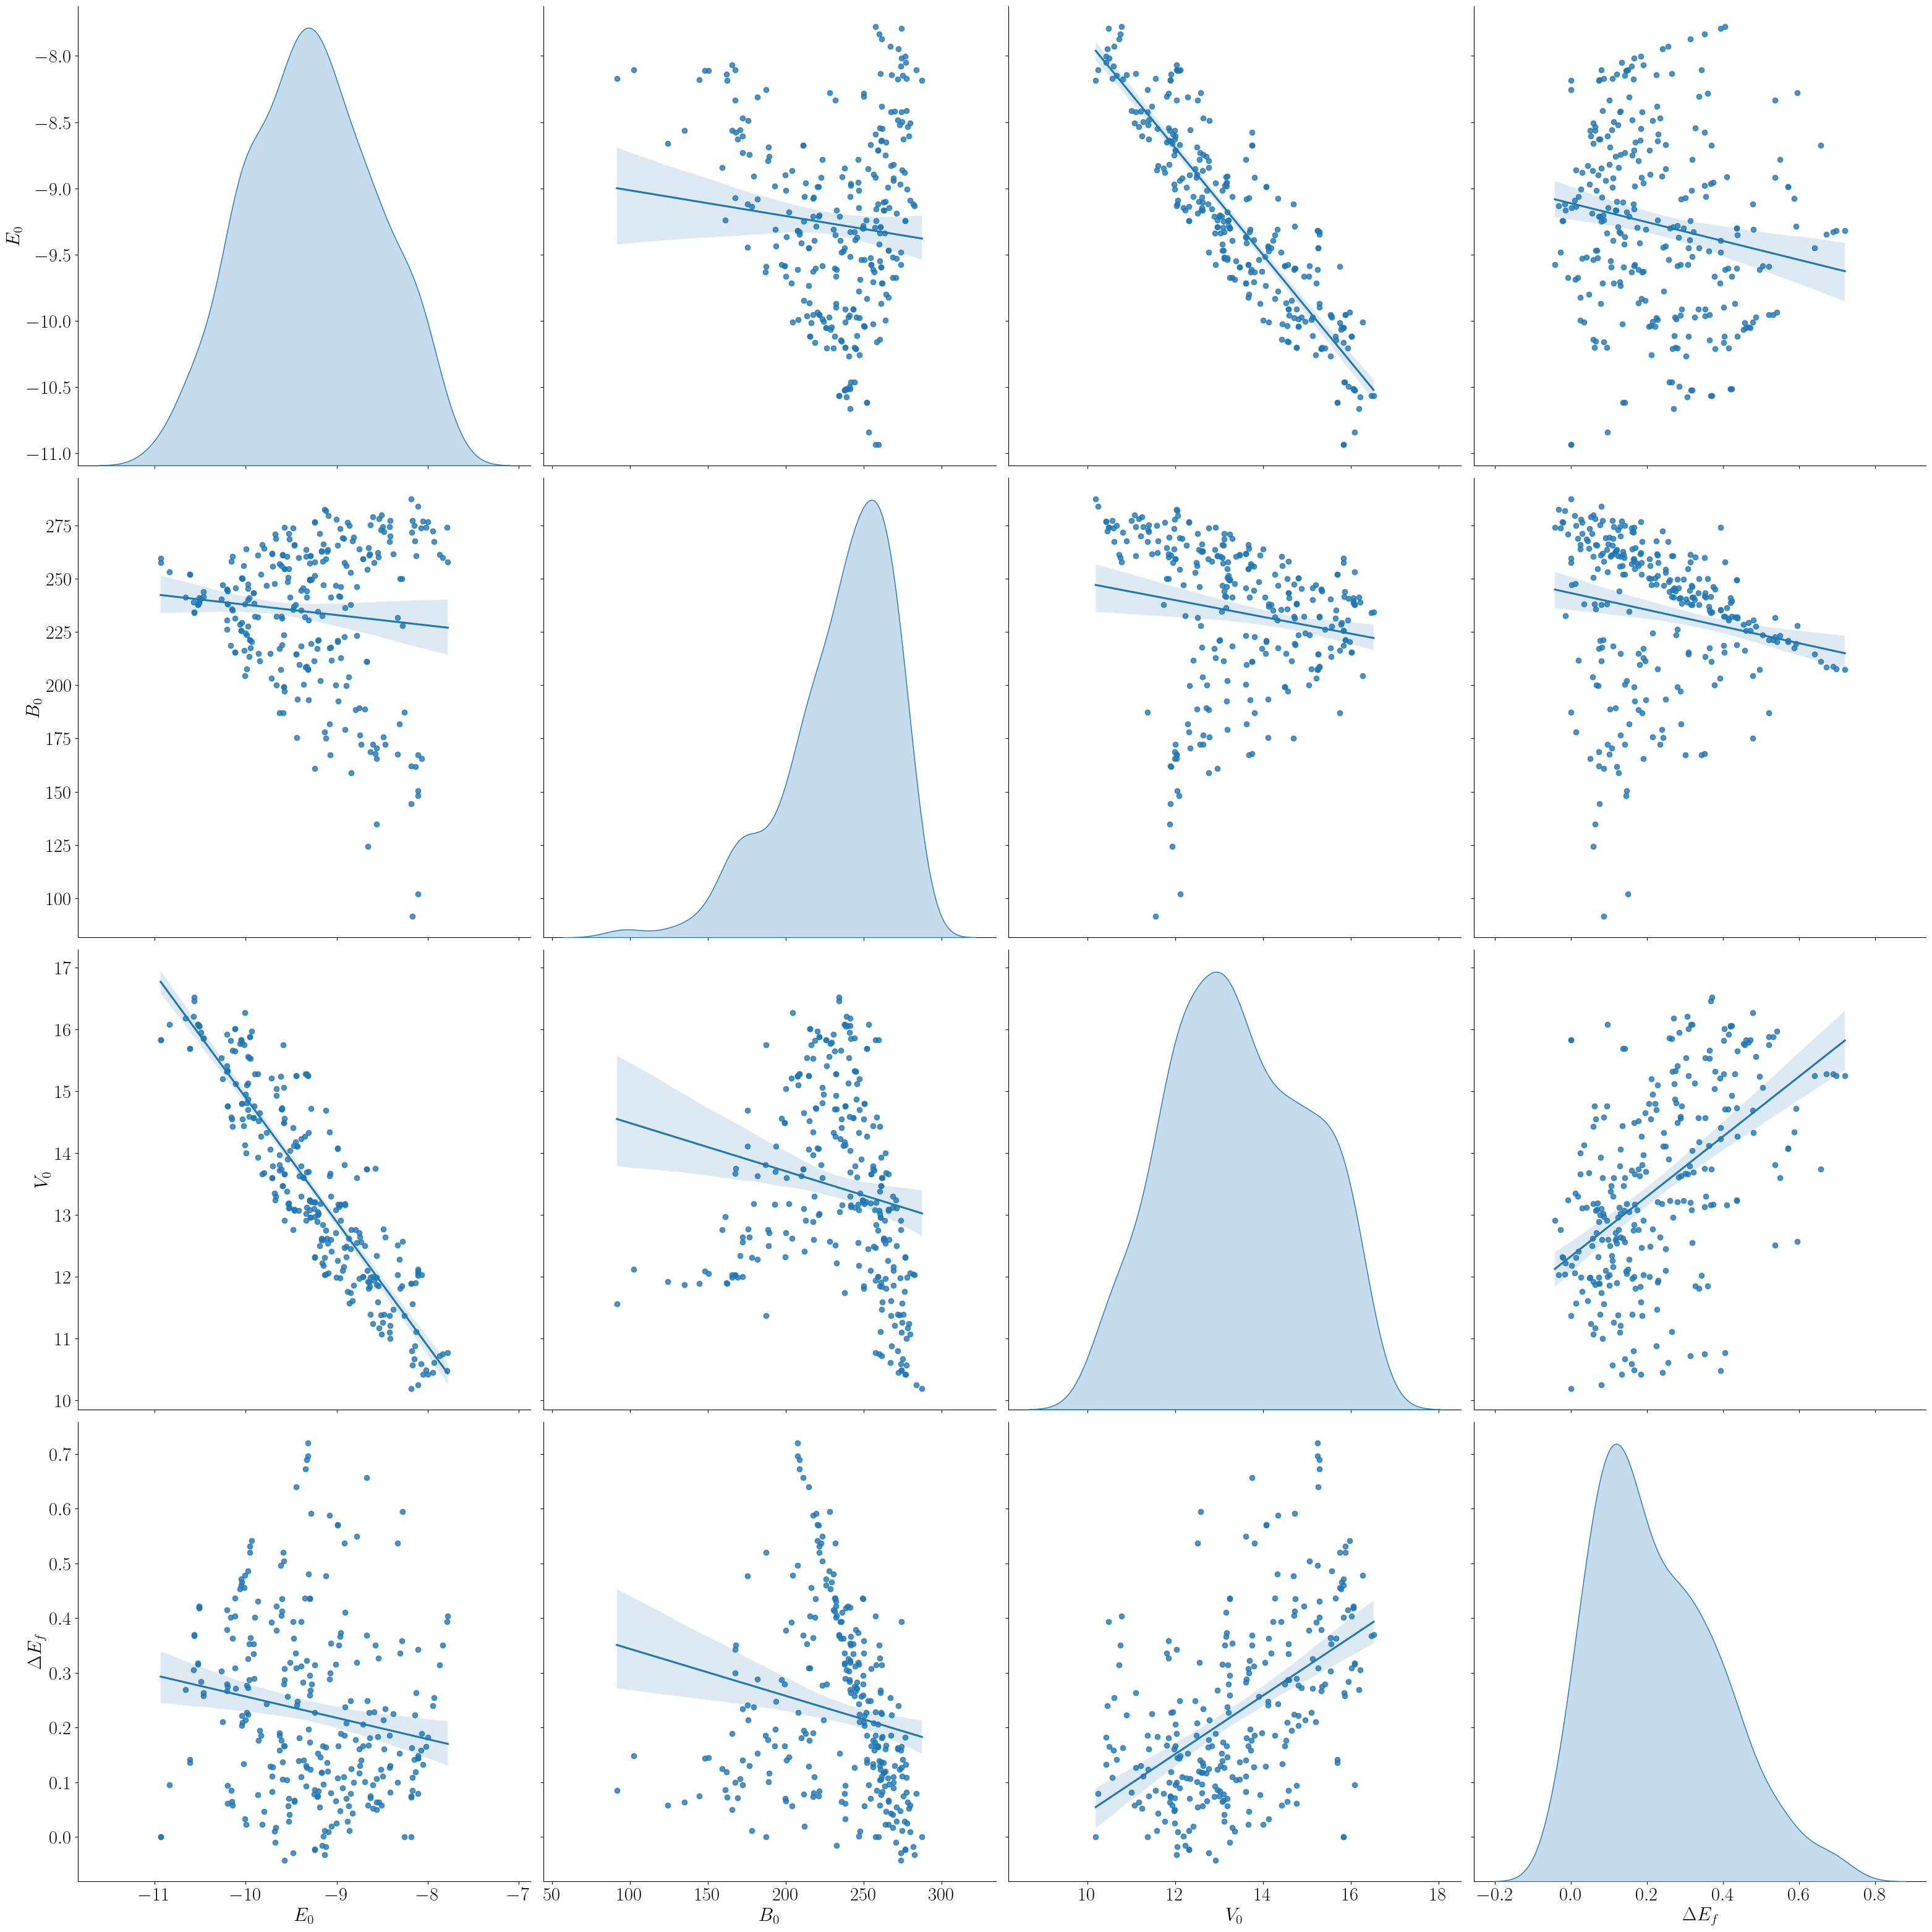

In [20]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# Magnetic vs Non Magnetic

In [21]:
EFFM = BS[target_case][Features.Mag == 'FM']

In [22]:
EFNMfcc = BS[target_case][Features.Mag == 'NM']

In [23]:
EFNMhcp = BS[target_case][Features.Mag == 'NM']

In [24]:
EFFM.index = EFFM.index.str.replace('.FM', '')

In [25]:
EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

In [26]:
EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

In [27]:
DE_mag  = EFNMhcp - EFFM 

In [28]:
DE_mag[ abs(DE_mag > 0.1)]

Fe_pv10Mo_sv2.C14-ABA        0.122327
Fe_pv10Mo_sv3.mu-BAAAB       0.111849
Fe_pv11Mo_sv2.mu-AAAAB       0.118739
Fe_pv12.C14                  0.165292
Fe_pv12Mo_sv1.mu-BAAAA       0.111532
Fe_pv13.mu                   0.135269
Fe_pv18Mo_sv6.C36-AAAAB      0.244699
Fe_pv1Mo_sv1.B2-AB           0.133134
Fe_pv20Mo_sv4.C36-AABAA      0.124745
Fe_pv24.C36                  0.205400
Fe_pv28Mo_sv2.sigma-BAAAA    0.123620
Fe_pv30.sigma                0.107503
Fe_pv4Mo_sv9.mu-BBAAB        0.120306
Fe_pv6.C15                   0.260263
Fe_pv6Mo_sv2.A15-AB          0.170837
Fe_pv8.A15                   0.154585
Name: EF_nmhcp, dtype: float64

In [29]:
DE_mag[DE_mag < 0 ]

Fe_pv10Mo_sv14.C36-BBAAB     -0.013983
Fe_pv10Mo_sv14.C36-BBABA     -0.027024
Fe_pv10Mo_sv20.sigma-ABBAB   -0.009727
Fe_pv12Mo_sv12.C36-BBBAA     -0.029356
Fe_pv12Mo_sv17.chi-BBBA      -0.029261
Fe_pv12Mo_sv18.sigma-BABAB   -0.001810
Fe_pv13Mo_sv16.chi-ABBA      -0.031720
Fe_pv16Mo_sv13.chi-BABA      -0.002677
Fe_pv16Mo_sv8.C36-BBAAA      -0.018599
Fe_pv1Mo_sv1.hcp-AB          -0.035365
Fe_pv1Mo_sv12.mu-ABBBB       -0.005354
Fe_pv1Mo_sv28.chi-ABBB       -0.002410
Fe_pv2.hcp                   -0.189213
Fe_pv24Mo_sv5.chi-BBAA       -0.005947
Fe_pv25Mo_sv4.chi-ABAA       -0.005665
Fe_pv2Mo_sv11.mu-BBBAB       -0.010859
Fe_pv2Mo_sv28.sigma-ABBBB    -0.004686
Fe_pv2Mo_sv6.D0_19-AB3       -0.017667
Fe_pv3Mo_sv1.L12-A3B         -0.036167
Fe_pv4Mo_sv2.C15-A2B         -0.002823
Fe_pv4Mo_sv20.C36-BABBB      -0.011770
Fe_pv4Mo_sv20.C36-BBABB      -0.004556
Fe_pv4Mo_sv8.C14-ABB         -0.023572
Fe_pv6Mo_sv18.C36-BBBBA      -0.017666
Fe_pv6Mo_sv6.C14-BBA         -0.028564
Fe_pv6Mo_sv7.mu-BABBB    

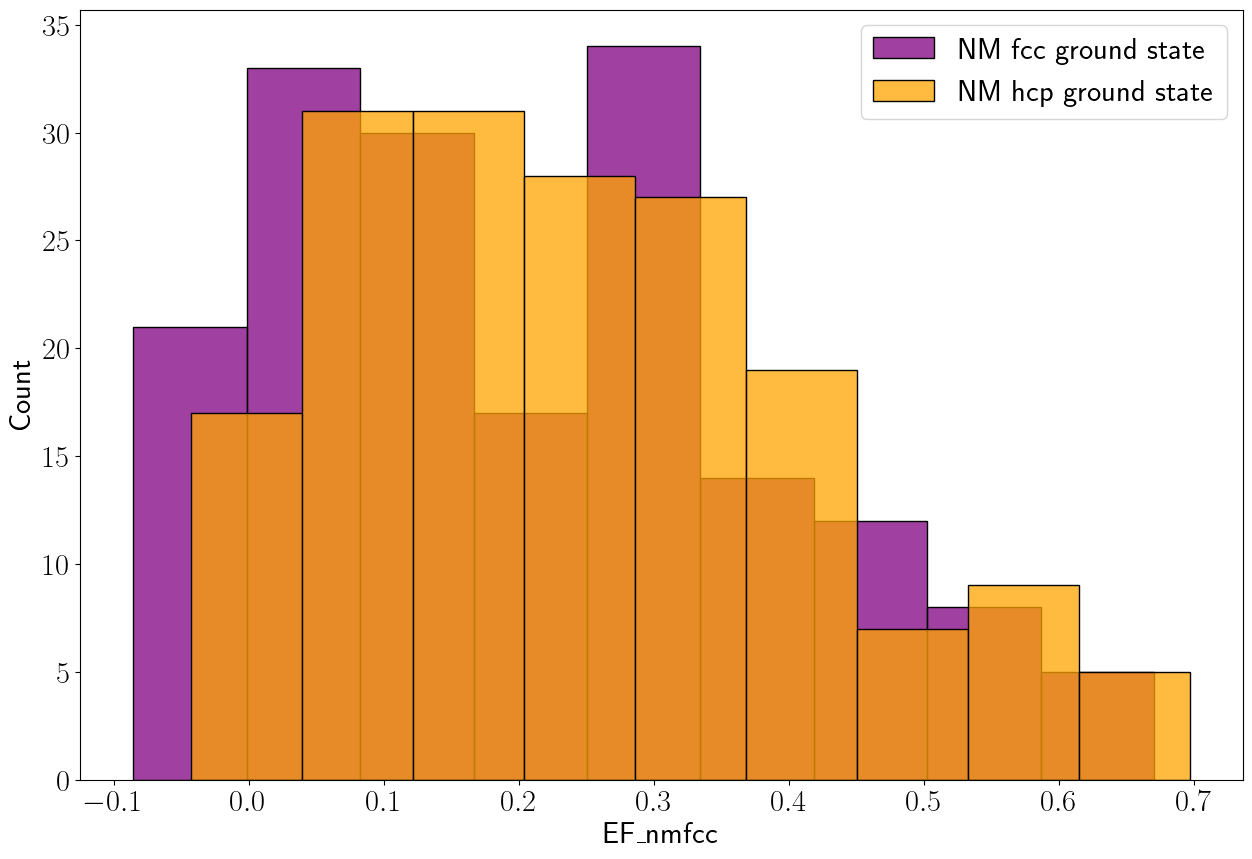

In [30]:
ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmfcc'], color = 'purple', label = "NM fcc ground state")
ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmhcp'], color='orange', label ='NM hcp ground state')
ax.legend()

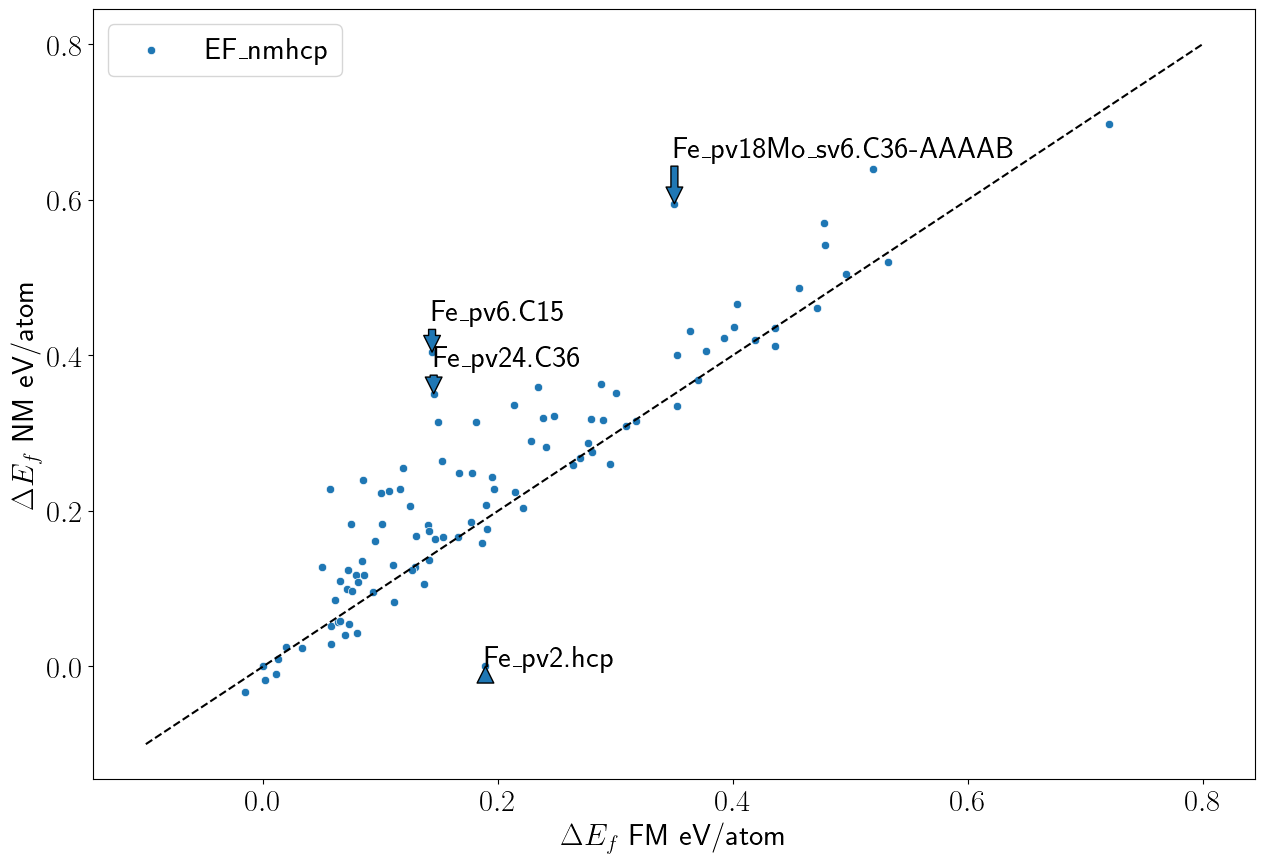

In [31]:
x = [-0.1, 0.8] 
y = [-0.1, 0.8]
ax  = sns.scatterplot(EFFM, EFNMhcp, label=target_case)
ax  = sns.scatterplot(EFFM, EFNMfcc, label=target_case, ax=ax, color='purple', size = 20)
ax.plot(x,y, '--k')
ax.set_xlabel(r'$\Delta E _f $ FM  eV/atom')
ax.set_ylabel(r'$\Delta E _f $ NM  eV/atom ')
big_difference = DE_mag[DE_mag.abs()>0.18].index#.index[0]
for bigdifindex in big_difference:
    xy = (EFFM[bigdifindex], EFNMhcp[bigdifindex])
    xytext = (EFFM[bigdifindex],  EFNMhcp[bigdifindex]*1.1)
    ax.annotate(bigdifindex, xy , xytext = xytext, arrowprops={'width': 5, })

In [32]:
BIGDIF_FM = BS.filter(regex='E0|atom_').loc[big_difference+'.FM']

In [33]:
BIGDIF_NM = BS.filter(regex='E0|atom_').loc[big_difference+'.NM']

In [34]:
pd.concat([BIGDIF_FM, BIGDIF_NM], axis = 0)

,E0,atom_A,atom_B,num_atom_A,num_atom_B
Fe_pv18Mo_sv6.C36-AAAAB.FM,-8.574181,Fe_pv,Mo_sv,18,6
Fe_pv2.hcp.FM,-8.065630,Fe_pv,,2,0
Fe_pv24.C36.FM,-8.109714,Fe_pv,,24,0
Fe_pv6.C15.FM,-8.111077,Fe_pv,,6,0
Fe_pv18Mo_sv6.C36-AAAAB.NM,-8.276410,Fe_pv,Mo_sv,18,6
Fe_pv2.hcp.NM,-8.184069,Fe_pv,,2,0
Fe_pv24.C36.NM,-7.833540,Fe_pv,,24,0
Fe_pv6.C15.NM,-7.780040,Fe_pv,,6,0


In [35]:
Features.get_ground_states_energies()

{('Fe_pv', 'FM', 'bcc'): -8.254843,
 ('Fe_pv', 'NM', 'hcp'): -8.184069,
 ('Mo_sv', 'FM', 'bcc'): -10.932791,
 ('Mo_sv', 'NM', 'bcc'): -10.932826}

In [36]:
EREF_FM = BS[BS.index.str.contains('FM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0']].sort_values(by='E0').iloc[0]

In [37]:
EREF_FM

E0   -8.254843
Name: Fe_pv2.bcc-cubic.FM, dtype: float64

In [38]:
BIGDIF_FM['E0'] - EREF_FM['E0']

Fe_pv18Mo_sv6.C36-AAAAB.FM   -0.319338
Fe_pv2.hcp.FM                 0.189213
Fe_pv24.C36.FM                0.145129
Fe_pv6.C15.FM                 0.143766
Name: E0, dtype: float64

In [39]:
EREF_NM = BS[BS.index.str.contains('NM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0', 'num_atom_A', 'num_atoms']].sort_values(by='E0').iloc[0]

In [40]:
EREF_NM

E0           -8.184069
num_atom_A    2.000000
num_atoms     2.000000
Name: Fe_pv2.hcp.NM, dtype: float64

In [41]:
BIGDIF_NM['E0'] - EREF_NM['E0']

Fe_pv18Mo_sv6.C36-AAAAB.NM   -0.092341
Fe_pv2.hcp.NM                 0.000000
Fe_pv24.C36.NM                0.350529
Fe_pv6.C15.NM                 0.404029
Name: E0, dtype: float64

In [42]:
BS.columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc', 'Phase'],
      dtype='object')

# NM convex hulls (binaries only)

In [43]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [44]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [45]:
verts = {}
chulls = {}
phasepoints = {}

PhasesBS = {mag: {phase: BS[(BS.Phase == phase) & BS.index.str.contains(mag)] for phase in BS.Phase.unique()} for mag in ['FM', 'NM', '']}

In [46]:
remove = []
for mag, phasesbs in PhasesBS.items():
    for phase, bs in phasesbs.items():
        if len(bs) < 3:
            remove.append((mag, phase))

In [47]:
[PhasesBS[remove_mag].pop(remove_phase) for (remove_mag, remove_phase) in remove]

[                                                      V        E0  \
 Fe_pv6.C15.FM                bulk  C15.FM  12.092153 A  -8.111077   
 Fe_pv4Mo_sv2.C15-A2B.FM  bulk  C15-A2B.FM  12.307425 A  -9.135294   
 
                                        B                         fit       xc  \
 Fe_pv6.C15.FM            148.116428 GPa   murnaghan  volume_relaxed   PBE-PAW   
 Fe_pv4Mo_sv2.C15-A2B.FM  177.924519 GPa   murnaghan  volume_relaxed   PBE-PAW   
 
                         encut deltak ncrash  nelem  ...  atom_B  num_atom_A  \
 Fe_pv6.C15.FM             450  0.021      0      1  ...                   6   
 Fe_pv4Mo_sv2.C15-A2B.FM   450  0.018      0      2  ...   Mo_sv           4   
 
                         num_atom_B num_atoms     Fe_pv     Mo_sv  EF_fmbcc  \
 Fe_pv6.C15.FM                    0         6  1.000000  0.000000  0.143766   
 Fe_pv4Mo_sv2.C15-A2B.FM          2         6  0.666667  0.333333  0.012198   
 
                          EF_nmhcp  EF_nmfcc  Phase  
 Fe_p

FM [('A15', 4), ('C14', 6), ('chi', 10), ('sigma', 30), ('C36', 19), ('mu', 21), ('hcp', 4), ('fcc', 4), ('bcc', 3)]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


NM [('A15', 4), ('C14', 8), ('chi', 16), ('sigma', 32), ('C15', 4), ('C36', 32), ('mu', 31), ('hcp', 5), ('fcc', 6), ('bcc', 6), ('R', 30)]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


 [('A15', 8), ('C14', 14), ('chi', 26), ('sigma', 62), ('C15', 6), ('C36', 51), ('mu', 52), ('hcp', 9), ('fcc', 10), ('bcc', 9), ('R', 30)]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


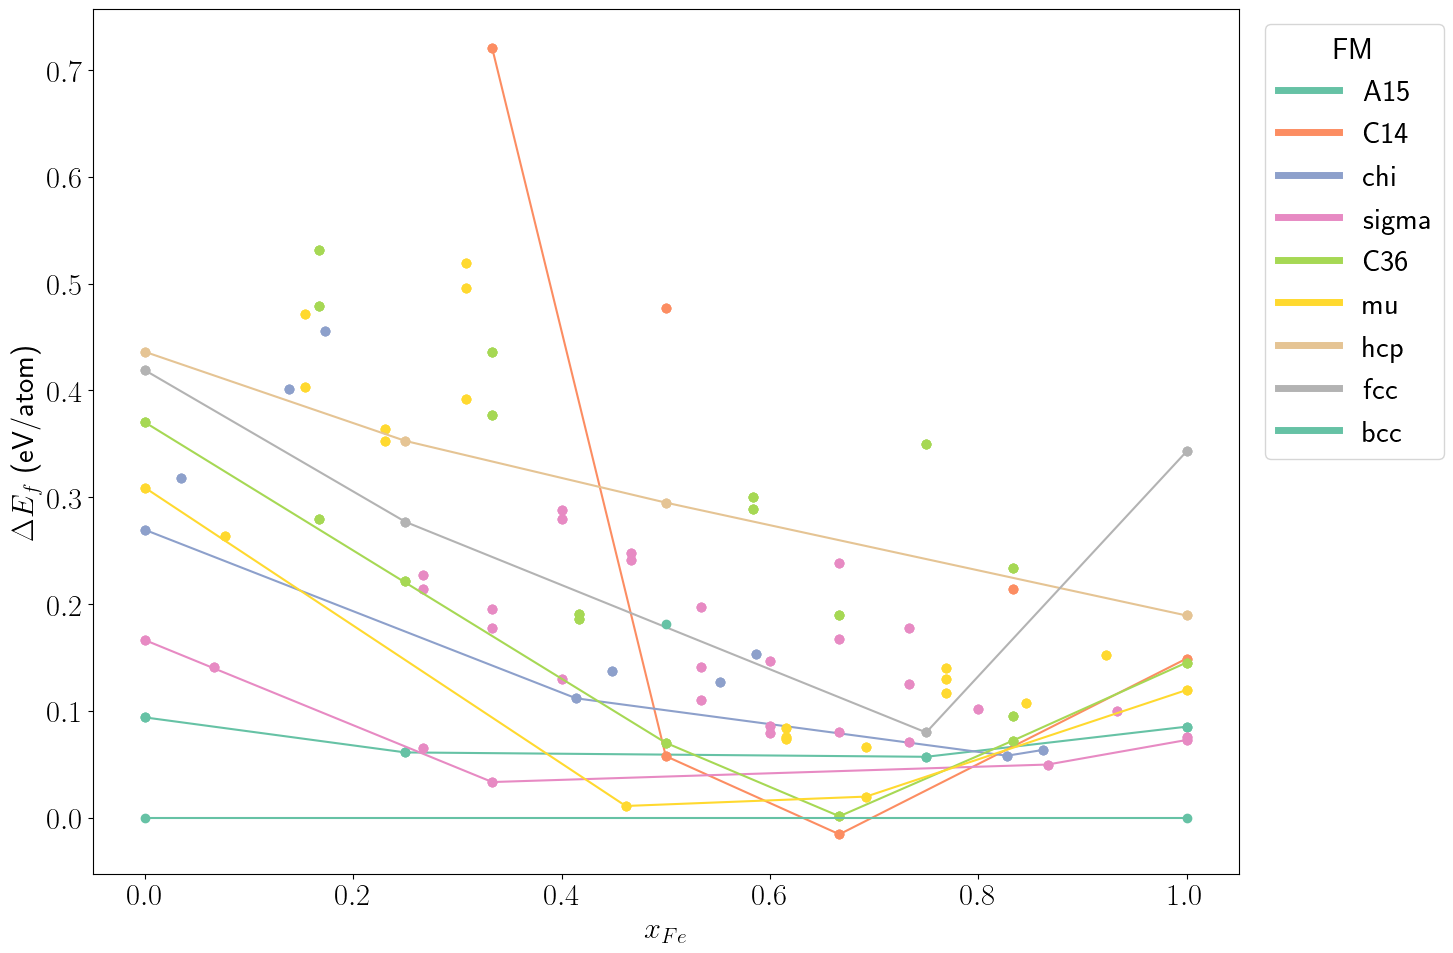

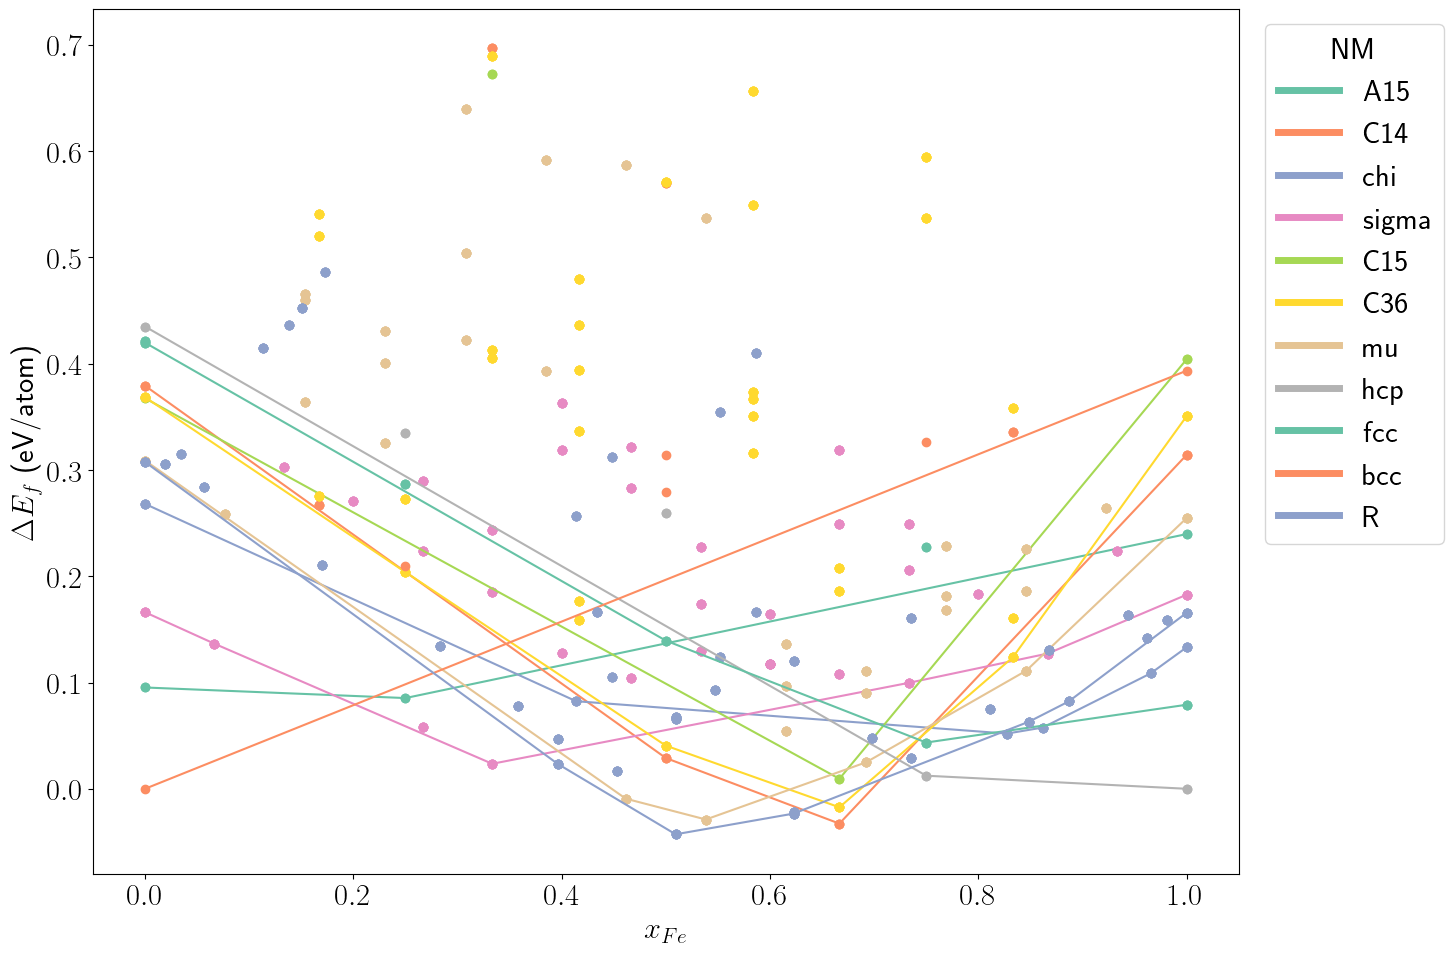

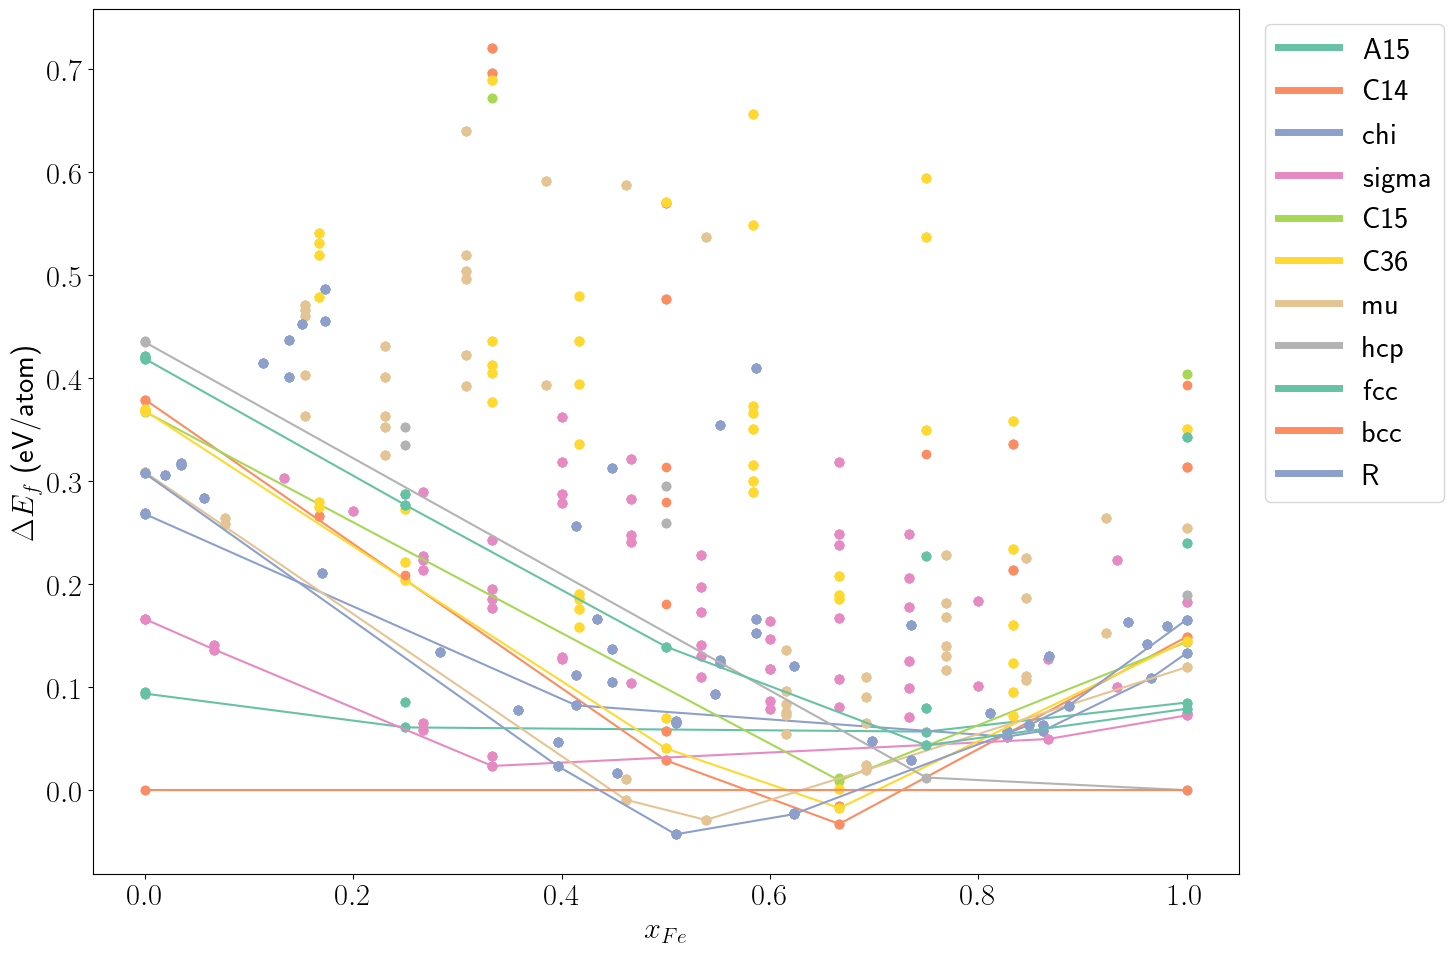

In [48]:
for mag, PhaseBS in  PhasesBS.items():
    print(mag, [(phase, len(BS))  for phase, BS in PhaseBS.items()] )
    points = P.get_x_ef_points(PhaseBS, components, property=target_case)
    chulls = P.get_convex_hulls(PhaseBS, components, return_points = False, getproperty = target_case)
    pallette = sns.color_palette("Set2", n_colors=len(PhaseBS)+1)
    #pallette.pop(-2)
    colors = {phase: color for phase, color in zip(PhaseBS.keys(), pallette)}
    fig, ax = plt.subplots()
    labels=[]
    handles = []
    for phase, chull in chulls.items():
        for visible_facet in chull.simplices[chull.good]:
            ax.plot(points[phase].iloc[:,0] , points[phase].iloc[:,1], 'o', color = colors[phase])
            l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase])
        handles.append(l[0])
        labels.append(phase)
    leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
    setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
    ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
    ax.set_xlabel(rf'$x_{{{components[0]}}}$')
    fig.tight_layout()
    fig.savefig(os.path.join(dataset, 'graphs',f'{dataset}_ConvxHulls_{target_case}_{mag}.eps' ))

In [49]:
BS.to_pickle(os.path.join(dataset, f'FurtherCuratedParsedBriefSummary.pkl'))